In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,Normalizer,OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.linear_model import LinearRegression,LogisticRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor,plot_tree
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import root_mean_squared_error,mean_squared_error,mean_absolute_error,accuracy_score,classification_report,confusion_matrix,r2_score,recall_score,f1_score
from sklearn.ensemble import AdaBoostClassifier,AdaBoostRegressor,GradientBoostingClassifier,GradientBoostingRegressor

import xgboost as xgb

import tensorflow 
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [54]:
df_imported =pd.read_csv("/Users/prathamsharma/Desktop/ELECTRICL SOP ZAFAR SIR/air_quality_health_impact_data.csv")

In [55]:
df_imported.columns

Index(['RecordID', 'AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3', 'Temperature',
       'Humidity', 'WindSpeed', 'RespiratoryCases', 'CardiovascularCases',
       'HospitalAdmissions', 'HealthImpactScore', 'HealthImpactClass'],
      dtype='object')

In [56]:
df = df_imported[[ "AQI" , "PM10" , "PM2_5" , "NO2" , "SO2" , "O3" , "Temperature" , "Humidity" , "WindSpeed" , "RespiratoryCases" , "CardiovascularCases" , "HospitalAdmissions" , "HealthImpactScore" ]]

In [57]:
df.columns

Index(['AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3', 'Temperature', 'Humidity',
       'WindSpeed', 'RespiratoryCases', 'CardiovascularCases',
       'HospitalAdmissions', 'HealthImpactScore'],
      dtype='object')

In [58]:
df.head()

,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore
0,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041
1,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000
2,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000
3,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000
4,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643


In [59]:
df.isnull().sum()

AQI                    0
PM10                   0
PM2_5                  0
NO2                    0
SO2                    0
O3                     0
Temperature            0
Humidity               0
WindSpeed              0
RespiratoryCases       0
CardiovascularCases    0
HospitalAdmissions     0
HealthImpactScore      0
dtype: int64

In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
df.describe()

,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore
count,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000
mean,248.438476,148.654997,100.223714,102.293445,49.456838,149.312431,14.975500,54.776853,9.989177,9.974187,4.988986,2.001033,93.785223
std,144.777638,85.698500,58.096612,57.713175,28.530329,86.534240,14.483067,26.020786,5.776950,3.129234,2.216791,1.398794,13.318904
min,0.005817,0.015848,0.031549,0.009625,0.011023,0.001661,-9.990998,10.001506,0.002094,1.000000,0.000000,0.000000,22.448488
25%,122.951293,75.374954,49.435171,53.538538,24.887264,73.999665,2.481500,31.995262,4.952343,8.000000,3.000000,1.000000,98.203057
50%,249.127841,147.634997,100.506337,102.987736,49.530165,149.559871,14.942428,54.543904,10.051742,10.000000,5.000000,2.000000,100.000000
75%,373.630668,222.436759,151.340260,151.658516,73.346617,223.380126,27.465374,77.641639,14.971840,12.000000,6.000000,3.000000,100.000000
max,499.858837,299.901962,199.984965,199.980195,99.969561,299.936812,39.963434,99.997493,19.999139,23.000000,14.000000,12.000000,100.000000


In [62]:
df.corr()

,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore
AQI,1.000000,0.023127,0.005890,0.007836,-0.006644,0.002339,0.004185,-0.004217,-0.018816,0.009302,0.009158,-0.013592,0.614560
PM10,0.023127,1.000000,-0.012193,0.008487,-0.007177,-0.004411,-0.017561,-0.017290,-0.018959,-0.001315,0.015582,-0.009076,0.182600
PM2_5,0.005890,-0.012193,1.000000,0.005564,0.015894,0.006070,-0.001978,0.006720,0.009041,0.025244,0.017312,-0.023123,0.220347
NO2,0.007836,0.008487,0.005564,1.000000,-0.019979,-0.014910,0.006971,-0.011100,-0.001398,0.019849,-0.005012,-0.002859,0.124435
SO2,-0.006644,-0.007177,0.015894,-0.019979,1.000000,-0.004319,-0.022458,0.000910,-0.001617,0.011130,-0.002672,-0.010546,0.015535
O3,0.002339,-0.004411,0.006070,-0.014910,-0.004319,1.000000,-0.001257,0.003982,-0.002596,-0.010068,0.001753,-0.014293,0.157940
Temperature,0.004185,-0.017561,-0.001978,0.006971,-0.022458,-0.001257,1.000000,-0.000233,0.000887,0.009394,0.009249,0.007943,-0.010556
Humidity,-0.004217,-0.017290,0.006720,-0.011100,0.000910,0.003982,-0.000233,1.000000,0.021027,0.008691,-0.024617,-0.004865,0.000662
WindSpeed,-0.018816,-0.018959,0.009041,-0.001398,-0.001617,-0.002596,0.000887,0.021027,1.000000,-0.010553,0.003715,-0.006454,-0.025447
RespiratoryCases,0.009302,-0.001315,0.025244,0.019849,0.011130,-0.010068,0.009394,0.008691,-0.010553,1.000000,-0.002621,0.009679,0.019268


In [63]:
df.corr()["HealthImpactScore"]

AQI                    0.614560
PM10                   0.182600
PM2_5                  0.220347
NO2                    0.124435
SO2                    0.015535
O3                     0.157940
Temperature           -0.010556
Humidity               0.000662
WindSpeed             -0.025447
RespiratoryCases       0.019268
CardiovascularCases   -0.008857
HospitalAdmissions    -0.029304
HealthImpactScore      1.000000
Name: HealthImpactScore, dtype: float64

In [64]:
print(df.shape)

(5811, 13)


In [65]:
x = df.drop("HealthImpactScore" , axis =1 )
y= df["HealthImpactScore"]

In [66]:
x.columns

Index(['AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3', 'Temperature', 'Humidity',
       'WindSpeed', 'RespiratoryCases', 'CardiovascularCases',
       'HospitalAdmissions'],
      dtype='object')

In [67]:
x.shape

(5811, 12)

In [68]:
y.shape

(5811,)

In [69]:
x_train , x_test , y_train ,y_test = train_test_split( x , y , test_size=0.2 , random_state = 42 )

In [70]:
print( x_train.shape , x_test.shape , y_train.shape , y_test.shape )

(4648, 12) (1163, 12) (4648,) (1163,)


In [71]:
std = StandardScaler()

x_train_stanadrdized = std.fit_transform(x_train)
x_test_stanadrdized = std.transform(x_test)

In [72]:
x_train_stanadrdized

array([[-0.02077126, -1.1196189 , -1.49914455, ...,  0.32967174,
        -0.44828243,  0.71653624],
       [ 1.62281729,  0.90695255,  1.47380502, ..., -0.31253876,
         0.00596146, -0.70552202],
       [ 1.05225865,  1.51118565, -1.35051841, ..., -0.63364401,
         0.91444925,  0.71653624],
       ...,
       [ 0.29464562, -0.85397204, -0.59357386, ...,  0.00856649,
         0.91444925,  0.71653624],
       [-1.24412416, -0.38208981,  0.37077766, ..., -1.91806501,
         2.27718093, -0.70552202],
       [ 0.96103792,  1.07927347, -0.96338341, ..., -0.31253876,
         0.00596146, -0.70552202]], shape=(4648, 12))

In [73]:
x_test_stanadrdized

array([[-0.87140374, -1.14002959, -0.71977202, ..., -1.59695976,
        -0.44828243,  0.00550711],
       [ 0.91282147,  1.52945532,  0.60628404, ...,  0.97188224,
        -0.44828243,  2.84962364],
       [ 1.64007407, -0.31240841, -1.45933086, ...,  0.32967174,
         0.91444925,  1.42756538],
       ...,
       [ 1.12907453,  0.79163237,  0.72922108, ...,  1.29298749,
        -1.81101411, -0.70552202],
       [ 0.14445676, -0.24289458, -0.06845348, ..., -0.31253876,
         0.00596146, -1.41655116],
       [ 1.67426547, -1.57633847, -0.74001818, ..., -0.63364401,
        -0.44828243,  0.00550711]], shape=(1163, 12))

In [74]:
model = Sequential()

model.add(Dense( 64 , activation="relu" , input_dim = 12))

model.add(Dense( 64 , activation="relu" ))

model.add(Dense( 32 , activation="relu" ))

model.add(Dense( 8 , activation="relu" ))

model.add(Dense(1))

/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [75]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,345 (28.69 KB)

 Trainable params: 7,345 (28.69 KB)

 Non-trainable params: 0 (0.00 B)

In [76]:
model.compile( optimizer="Adam" , loss = "mse" , metrics=["mae"] )

In [77]:
history = model.fit( x_train_stanadrdized , y_train , batch_size= 20 , epochs= 30 , validation_split=0.2 )

Epoch 1/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3116.7795 - mae: 42.8785 - val_loss: 293.4783 - val_mae: 13.7125
Epoch 2/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step - loss: 259.1949 - mae: 12.8605 - val_loss: 220.8540 - val_mae: 11.8773
Epoch 3/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - loss: 203.8747 - mae: 11.3294 - val_loss: 184.7864 - val_mae: 10.8871
Epoch 4/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - loss: 175.4678 - mae: 10.5235 - val_loss: 159.6963 - val_mae: 9.9545
Epoch 5/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 581us/step - loss: 156.6362 - mae: 9.8906 - val_loss: 145.3489 - val_mae: 9.5464
Epoch 6/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - loss: 141.4051 - mae: 9.3877 - val_loss: 129.8589 - val_mae: 9.0400
Epoch 7/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - loss: 123.0508 - mae: 8.7341 - val_loss: 112.9835 - val_mae: 8.3780
Epoch 8/30
186/186 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step - loss: 97.6888 - mae: 7.7481 - val_loss: 92.8937 - val_mae: 7.6063
Epoc

[]

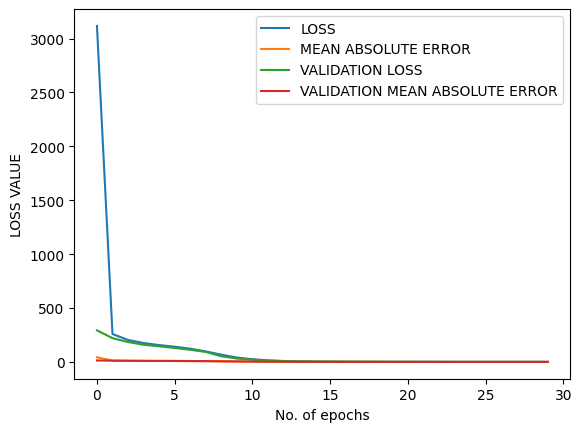

In [78]:
plt.plot( history.history["loss"] , label = "LOSS")

plt.plot( history.history["mae"] , label = "MEAN ABSOLUTE ERROR")

plt.plot( history.history["val_loss"] , label = "VALIDATION LOSS")

plt.plot( history.history["val_mae"] , label = "VALIDATION MEAN ABSOLUTE ERROR")

plt.xlabel("No. of epochs")

plt.ylabel("LOSS VALUE")

plt.legend()

plt.plot()

In [79]:
x_input1 = [[187.270059, 295.853039, 13.038560, 6.639263, 66.161150, 
        54.624280, 5.150335, 84.424344, 6.137755, 7, 5, 1]]


x_input1_scaled = std.transform(x_input1)

x_input1_resape = x_input1_scaled.reshape(1,-1)

y_pred_case1 = model.predict(x_input1_resape)
y_pred_case1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[97.78492]], dtype=float32)

In [80]:
x_input2 = [[78.009320, 16.987667, 152.111623, 121.235461, 90.866167,
             241.795138, 9.217517, 24.906837, 14.534733, 9, 0, 1]]

x_input2_scaled = std.transform(x_input2)

x_input2_reshape = x_input2_scaled.reshape(1, -1)

y_pred_case2 = model.predict(x_input2_reshape)
y_pred_case2

/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[94.10743]], dtype=float32)

In [81]:
x_input3 = [[475.357153, 246.254703, 9.984497, 16.318326, 90.499523,
             169.621728, 1.543378, 46.851415, 4.521422, 10, 2, 0]]

x_input3_scaled = std.transform(x_input3)

x_input3_reshape = x_input3_scaled.reshape(1, -1)

y_pred_case3 = model.predict(x_input3_reshape)
y_pred_case3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[99.52017]], dtype=float32)

In [82]:
x_input4 = [[365.996971, 84.443191, 23.111340, 96.317811, 17.875850,
             9.006794, 1.169483, 17.806977, 11.157384, 13, 3, 0]]

x_input4_scaled = std.transform(x_input4)

x_input4_reshape = x_input4_scaled.reshape(1, -1)

y_pred_case4 = model.predict(x_input4_reshape)
y_pred_case4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[99.95739]], dtype=float32)

In [83]:
x_input5 = [[299.329242, 21.020609, 14.273403, 81.234403, 48.323616,
             93.161033, 21.925276, 99.473373, 15.302500, 8, 8, 1]]

x_input5_scaled = std.transform(x_input5)

x_input5_reshape = x_input5_scaled.reshape(1, -1)

y_pred_case5 = model.predict(x_input5_reshape)
y_pred_case5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


/opt/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[100.431175]], dtype=float32)

In [85]:
y_pred = model.predict(x_test_stanadrdized)

print(y_pred)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step
[[ 85.11548 ]
 [ 99.98972 ]
 [100.073975]
 ...
 [100.07789 ]
 [100.427925]
 [ 99.85338 ]]


In [86]:
rmse = root_mean_squared_error(y_test , y_pred)
print("RMSE:",rmse)

RMSE: 0.576356525682851
